In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [33]:
df = pd.read_csv("PlayGolfData.csv")
df.head()

,Unnamed: 0,Date,Weekday,Month,Temperature,Humidity,Wind,Outlook,Crowdedness
0,0,03-25,Mon,Mar,High,Dry,No,sunny,85
1,1,03-26,Tue,Mar,Low,Humid,Yes,rainy,30
2,2,03-27,Wed,Mar,High,Dry,Yes,overcast,65
3,3,03-28,Thu,Mar,Extreme,Dry,Yes,sunny,45
4,4,03-29,Fri,Mar,Low,Humid,No,rainy,25


In [4]:
df = df.drop(columns="Unnamed: 0")

In [5]:
df.head()

,Date,Weekday,Month,Temperature,Humidity,Wind,Outlook,Crowdedness
0,03-25,Mon,Mar,High,Dry,No,sunny,85
1,03-26,Tue,Mar,Low,Humid,Yes,rainy,30
2,03-27,Wed,Mar,High,Dry,Yes,overcast,65
3,03-28,Thu,Mar,Extreme,Dry,Yes,sunny,45
4,03-29,Fri,Mar,Low,Humid,No,rainy,25


In [6]:
df2 = df.copy()

In [7]:
df2["Weekday"].unique()

array(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'], dtype=object)

In [8]:
cols_name = {"Weekday" : {"Mon" : 1, "Tue" : 2, 'Wed' : 3, 'Thu' : 4, 'Fri' : 5, 'Sat' : 6, 'Sun' : 7}}

In [9]:
df2 = df2.replace(cols_name)
df2.head()

/tmp/ipykernel_24347/1622986362.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df2 = df2.replace(cols_name)


,Date,Weekday,Month,Temperature,Humidity,Wind,Outlook,Crowdedness
0,03-25,1,Mar,High,Dry,No,sunny,85
1,03-26,2,Mar,Low,Humid,Yes,rainy,30
2,03-27,3,Mar,High,Dry,Yes,overcast,65
3,03-28,4,Mar,Extreme,Dry,Yes,sunny,45
4,03-29,5,Mar,Low,Humid,No,rainy,25


In [10]:
df2["Month"].unique()

array(['Mar', 'Apr'], dtype=object)

In [11]:
df2 = pd.get_dummies(df2, columns=["Month"], prefix="Mon")

In [12]:
df2.head()

,Date,Weekday,Temperature,Humidity,Wind,Outlook,Crowdedness,Mon_Apr,Mon_Mar
0,03-25,1,High,Dry,No,sunny,85,False,True
1,03-26,2,Low,Humid,Yes,rainy,30,False,True
2,03-27,3,High,Dry,Yes,overcast,65,False,True
3,03-28,4,Extreme,Dry,Yes,sunny,45,False,True
4,03-29,5,Low,Humid,No,rainy,25,False,True


In [13]:
df3 = df2.copy()

In [14]:
sorted(df3["Temperature"].unique())

['Extreme', 'High', 'Low']

In [16]:
df3["Temperature"] = df3["Temperature"].astype("category")

In [15]:
df3.dtypes

,0
Date,object
Weekday,int64
Temperature,object
Humidity,object
Wind,object
Outlook,object
Crowdedness,int64
Mon_Apr,bool
Mon_Mar,bool


In [17]:
df3["Temperature_encoded"] = df3["Temperature"].cat.codes

In [18]:
df3.head()

,Date,Weekday,Temperature,Humidity,Wind,Outlook,Crowdedness,Mon_Apr,Mon_Mar,Temperature_encoded
0,03-25,1,High,Dry,No,sunny,85,False,True,1
1,03-26,2,Low,Humid,Yes,rainy,30,False,True,2
2,03-27,3,High,Dry,Yes,overcast,65,False,True,1
3,03-28,4,Extreme,Dry,Yes,sunny,45,False,True,0
4,03-29,5,Low,Humid,No,rainy,25,False,True,2


In [19]:
sorted(df3["Outlook"].unique())


['overcast', 'rainy', 'sunny']

In [20]:
df3["Outlook"] = df3["Outlook"].astype("category")
df3["Outlook_encoded"] = df3["Outlook"].cat.codes
df3.head()

,Date,Weekday,Temperature,Humidity,Wind,Outlook,Crowdedness,Mon_Apr,Mon_Mar,Temperature_encoded,Outlook_encoded
0,03-25,1,High,Dry,No,sunny,85,False,True,1,2
1,03-26,2,Low,Humid,Yes,rainy,30,False,True,2,1
2,03-27,3,High,Dry,Yes,overcast,65,False,True,1,0
3,03-28,4,Extreme,Dry,Yes,sunny,45,False,True,0,2
4,03-29,5,Low,Humid,No,rainy,25,False,True,2,1


In [21]:
df4 = df3.copy()

In [22]:
df4 = pd.get_dummies(df4, columns=["Wind"], prefix="Wind")
df4.head()

,Date,Weekday,Temperature,Humidity,Outlook,Crowdedness,Mon_Apr,Mon_Mar,Temperature_encoded,Outlook_encoded,Wind_No,Wind_Yes
0,03-25,1,High,Dry,sunny,85,False,True,1,2,True,False
1,03-26,2,Low,Humid,rainy,30,False,True,2,1,False,True
2,03-27,3,High,Dry,overcast,65,False,True,1,0,False,True
3,03-28,4,Extreme,Dry,sunny,45,False,True,0,2,False,True
4,03-29,5,Low,Humid,rainy,25,False,True,2,1,True,False


<Axes: xlabel='Crowdedness', ylabel='Count'>

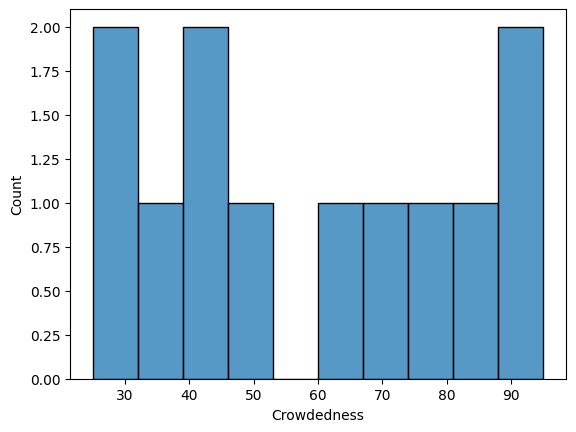

In [23]:
sns.histplot(x=df["Crowdedness"], bins=10)

In [24]:
df["Crowdedness"].describe()

,Crowdedness
count,12.000000
mean,59.583333
std,24.444588
min,25.000000
25%,42.500000
50%,57.500000
75%,81.250000
max,95.000000


The upper analysis shows:
The Crowdedness data is ranges from 25 to 95

In [25]:
df["Crowdedness"].value_counts()

,count
Crowdedness,
45,2
30,1
85,1
65,1
25,1
90,1
95,1
35,1
70,1


In [26]:
low_crowd_cond = np.min(df["Crowdedness"]) + (np.max(df["Crowdedness"]) - np.min(df["Crowdedness"])) / 3
med_crowd_cond = low_crowd_cond + (np.max(df["Crowdedness"]) - np.min(df["Crowdedness"])) / 3
high_crowd_cond = med_crowd_cond + (np.max(df["Crowdedness"]) - np.min(df["Crowdedness"])) / 3

In [27]:
print(low_crowd_cond)
print(med_crowd_cond)
print(high_crowd_cond)

48.33333333333333
71.66666666666666
94.99999999999999


In [28]:
def crowd_cat(Crowdedness):
    if Crowdedness < low_crowd_cond:
        r = 1
    elif Crowdedness < med_crowd_cond:
        r = 2
    elif Crowdedness < high_crowd_cond:
        r = 3
    return r

In [30]:
df4["Crowdedness_Encoded"] = df4["Crowdedness"].apply(crowd_cat)
df4.head()

,Date,Weekday,Temperature,Humidity,Outlook,Crowdedness,Mon_Apr,Mon_Mar,Temperature_encoded,Outlook_encoded,Wind_No,Wind_Yes,Crowdedness_Encoded
0,03-25,1,High,Dry,sunny,85,False,True,1,2,True,False,3
1,03-26,2,Low,Humid,rainy,30,False,True,2,1,False,True,1
2,03-27,3,High,Dry,overcast,65,False,True,1,0,False,True,2
3,03-28,4,Extreme,Dry,sunny,45,False,True,0,2,False,True,1
4,03-29,5,Low,Humid,rainy,25,False,True,2,1,True,False,1


In [31]:
df_encoded = df4[["Weekday" ,"Mon_Apr",	"Mon_Mar",	"Temperature_encoded", "Outlook_encoded", "Wind_No", "Wind_Yes", "Crowdedness_Encoded"]].copy()


In [32]:
df_encoded.head()

,Weekday,Mon_Apr,Mon_Mar,Temperature_encoded,Outlook_encoded,Wind_No,Wind_Yes,Crowdedness_Encoded
0,1,False,True,1,2,True,False,3
1,2,False,True,2,1,False,True,1
2,3,False,True,1,0,False,True,2
3,4,False,True,0,2,False,True,1
4,5,False,True,2,1,True,False,1
